# Mini-Projeto 01 - Análise Exploratória de Dados no Varejo

## Introdução

Este mini-projeto tem como objetivo realizar uma Análise Exploratória de Dados (AED) utilizando uma base de varejo. A proposta é transformar dados brutos de compras em informações organizadas, identificando características da base, possíveis problemas de qualidade e padrões relevantes sobre clientes, produtos e categorias.

A base analisada contém registros de compras com informações como data da transação, identificação do cliente, gênero, estado civil, número de filhos, segmento do cliente, identificação do produto, categoria e nome do produto. A partir desses dados, será possível praticar etapas importantes de um projeto de análise de dados, como carregamento da base, verificação dos tipos de dados, tratamento de valores nulos, remoção de colunas irrelevantes, conversão de datas e criação de estatísticas descritivas.

Além da limpeza e preparação dos dados, o projeto também busca responder perguntas operacionais simples, como quais categorias aparecem com maior frequência, quais perfis de clientes concentram mais registros de compra e como os dados estão distribuídos ao longo do tempo. Essas análises ajudam a compreender melhor o comportamento da base e servem como ponto de partida para visualizações, relatórios ou dashboards.

Ao final, espera-se apresentar os principais insights encontrados e registrar eventuais limitações ou problemas remanescentes nos dados, comunicando os resultados de forma clara e objetiva.


In [1]:
# Importa bibliotecas e implementa a função de extração dos dados para o ambiente de desenvolvimento

import kagglehub
import shutil
import pandas as pd
from pathlib import Path

def extrair_dados():
    path = kagglehub.dataset_download("namespaiva/base-varejo")
    csv_path = Path(path) / "Base Varejo.csv"
    df = pd.read_csv(csv_path, sep=';', encoding='cp1252', decimal=',')
    return df


/Users/samuelbucco/Documents/SCTec/Análise de Dados/Etapa Profissionalizar/Mod 1 - Modelagem de Dados/turma-visualizacao-de-dados/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carrega o dataset para o ambiente de desenvolvimento a partir da função de extração implementada
df = extrair_dados()

print("Dataset carregado com sucesso!\n")
print(f"O dataframe tem {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Exibe as primeiras linhas do dataset
print(df.head().to_string())
print("\nColunas do dataset:", df.columns.tolist())
print("\nTipos de dados das colunas:\n", df.dtypes)


In [4]:
# ANÁLISE DA BASE DE DADOS

# Estatísticas descritivas
print("\nEstatísticas descritivas do dataset:\n")
print(df.describe(include="all").round(2).to_string())

# Quantidade de nulos por coluna
print("\nQuantidade de valores nulos por coluna:\n")
print(df.isnull().sum())

# Verificar valores únicos 
print("\nValores únicos por coluna:\n")
for coluna in df.columns:
    print(f"{coluna}: {df[coluna].nunique()} valores únicos")

# Quantidade de linhas duplicadas

linhas_duplicadas = df.duplicated().sum()
print(f"\nQuantidade de linhas duplicadas: {linhas_duplicadas}")



### Problemas encontrados na base

Após a verificação inicial, foram identificados alguns pontos de atenção:

- As colunas `Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12` e `Unnamed: 13` possuem todos os valores nulos, indicando que não trazem informação útil para a análise.
- A base foi verificada quanto à existência de linhas duplicadas.
- A coluna `DATA` foi testada para identificar possíveis datas inválidas.
- A coluna `PR_CAT` apresenta a categoria `#N/D`, que indica registros sem categoria de produto bem definida.

In [18]:
# LIMPEZA E TRATAMENTO DOS DADOS

# Remover colunas irrelevantes
colunas_irrelevantes = ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
df_limpo = df.copy()

df_limpo = df_limpo.drop(columns=colunas_irrelevantes)

print("Colunas removidas por conterem apenas valores nulos:\n")
print(colunas_irrelevantes)

# Converter coluna data para o formato datetime
df_limpo['DATA'] = pd.to_datetime(
    df_limpo['DATA'], 
    errors='coerce',
    format='%d/%m/%Y'
    )

# Verificar o número de datas inválidas após a conversão
datas_invalidas = df_limpo['DATA'].isnull().sum()
print(f"\nNúmero de datas inválidas após a conversão: {datas_invalidas}")

# Cria uma nova coluna para o ano e mes da data
df_limpo['ANO'] = df_limpo['DATA'].dt.year
df_limpo['MES'] = df_limpo['DATA'].dt.month

# Agrupar vendas por mês
vendas_ano_mes = df_limpo.groupby('MES')['PR_ID'].count().reset_index(name='QUANTIDADE_VENDAS')
print("\nQuantidade de vendas por mês:\n")
print(vendas_ano_mes.to_string(index=False))

# Agrupar vendas por ano
vendas_ano = df_limpo.groupby('ANO')['PR_ID'].count().reset_index(name='QUANTIDADE_VENDAS')
print("\nQuantidade de vendas por ano:\n")
print(vendas_ano.to_string(index=False))

# Remover linhas duplicadas
linhas_duplicadas_antes_limpeza = df_limpo.duplicated().sum()

df_limpo = df_limpo.drop_duplicates()

linhas_duplicadas_apos_limpeza = df_limpo.duplicated().sum()

print(f"\nQuantidade de linhas duplicadas antes da limpeza: {linhas_duplicadas_antes_limpeza}")
print(f"Quantidade de linhas duplicadas após a limpeza: {linhas_duplicadas_apos_limpeza}")
print(f"Formato da base após remoção de duplicatas: {df_limpo.shape}\n")



Colunas removidas por conterem apenas valores nulos:

['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Número de datas inválidas após a conversão: 0

Quantidade de vendas por mês:

 MES  QUANTIDADE_VENDAS
   1              83963
   2              76201
   3              64371
   4              66935
   5              82275
   6              67808
   7              68983
   8              65609
   9              68594
  10              73900
  11              40912
  12              70449

Quantidade de vendas por ano:

 ANO  QUANTIDADE_VENDAS
2019             199036
2020             218367
2021             245259
2022             167338

Quantidade de linhas duplicadas antes da limpeza: 96553
Quantidade de linhas duplicadas após a limpeza: 0
Formato da base após remoção de duplicatas: (733447, 12)



In [25]:
# Tratamento de categoria inconsistente da coluna PR_CAT e PR_NOME

df_limpo["PR_CAT"] = df_limpo["PR_CAT"].replace("#N/D", "SEM CATEGORIA")


print("Contagem de valores únicos por categoria após tratamento:\n")

print(df_limpo["PR_CAT"].value_counts().reset_index(name='QUANTIDADE').rename(columns={'PR_CAT': 'CATEGORIA'}).to_string(index=False))
print()

print("Contagem de valores únicos por nome após tratamento:\n")

print(df_limpo["PR_NOME"].value_counts().reset_index(name='QUANTIDADE').rename(columns={'PR_NOME': 'NOME'}).to_string(index=False))

Contagem de valores únicos por categoria após tratamento:

    CATEGORIA  QUANTIDADE
    ALIMENTOS      384197
      HIGIENE      137702
      LIMPEZA      128632
      BEBIDAS       38264
          PET       28553
   ACESSORIOS       12871
SEM CATEGORIA        3228

Contagem de valores únicos por nome após tratamento:

                      NOME  QUANTIDADE
           PRESUNTO COZIDO       12719
                  SARDINHA        6610
                    BANANA        6518
           ESCOVA DE DENTE        6518
                       GEL        6517
          PAPINHA INFANTIL        6515
                 MODELADOR        6505
                      CERA        6502
        LIMPADOR PERFUMADO        6501
                    CEBOLA        6501
           DESENGORDURANTE        6500
                 REMOVEDOR        6493
                 COGUMELOS        6487
                DETERGENTE        6484
                    RICOTA        6479
           PAPEL HIGIENICO        6477
       REFRIGER

As colunas `Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12` e `Unnamed: 13` foram removidas porque possuem 100% dos valores nulos. Como essas colunas não apresentam informação útil para a análise, a melhor escolha foi removê-las em vez de imputar valores.

As linhas duplicadas foram removidas para evitar contagens repetidas nas análises. Esse tratamento é importante porque registros duplicados podem distorcer resultados como quantidade de compras, produtos mais frequentes e análises por categoria.

A coluna `DATA` foi convertida para o tipo `datetime`, permitindo análises temporais. 

Na coluna `PR_CAT`, o valor `#N/D` foi substituído por `SEM CATEGORIA`, pois indica produtos sem categoria definida. A opção foi manter esses registros na base, já que eles ainda podem conter informações úteis sobre clientes, datas e produtos.

In [29]:
# TRATAMENTO E EXPLORAÇÃO DE DADOS CATEGÓRICOS

# Criar colunas categóricas a partir da coluna 'CL_EC'
estado_civil_map = {
    1: "Casado/União Estável",
    2: "Divorciado",
    3: "Separado",
    4: "Solteiro",
    5: "Viúvo"
}
df_limpo['CL_EC_CATEGORIA'] = df_limpo['CL_EC'].map(estado_civil_map)

# Transformar colunas string para categóricas
colunas_categoricas = ['CL_EC_CATEGORIA', 'CL_GENERO', 'CL_SEG', 'PR_CAT', 'PR_NOME']
for coluna in colunas_categoricas:
    df_limpo[coluna] = df_limpo[coluna].astype('category')

# Verificar se a conversão foi bem-sucedida
print("\nTipos de dados após conversão:", df_limpo.dtypes)

# Explorando colunas categóricas

for coluna in colunas_categoricas:
    print(f"\nValores únicos na coluna (primeiros 10) '{coluna}':\n")
    print(df_limpo[coluna].value_counts().head(10).to_string())



Tipos de dados após conversão: DATA               datetime64[us]
CO_ID                       int64
CL_ID                       int64
CL_GENERO                category
CL_EC                       int64
CL_FHL                      int64
CL_SEG                   category
PR_ID                       int64
PR_CAT                   category
PR_NOME                  category
ANO                         int32
MES                         int32
CL_EC_CATEGORIA          category
dtype: object

Valores únicos na coluna (primeiros 10) 'CL_EC_CATEGORIA':

CL_EC_CATEGORIA
Separado                189048
Solteiro                179206
Divorciado              172283
Casado/União Estável    172010
Viúvo                    20900

Valores únicos na coluna (primeiros 10) 'CL_GENERO':

CL_GENERO
F    382427
M    351020

Valores únicos na coluna (primeiros 10) 'CL_SEG':

CL_SEG
B    468505
C    205265
A     59677

Valores únicos na coluna (primeiros 10) 'PR_CAT':

PR_CAT
ALIMENTOS        384197
HIGIENE      

Nesta etapa, as variáveis categóricas da base foram preparadas para facilitar a análise. A coluna `CL_EC`, que representa o estado civil do cliente por meio de códigos numéricos, foi transformada em uma nova coluna com descrições mais claras.

Também foram convertidas para o tipo `category` as colunas que representam grupos ou classificações, como gênero, segmento do cliente, categoria do produto e nome do produto. Essa conversão melhora a organização dos dados e facilita a exploração das frequências de cada categoria.

Por fim, foram exibidos os principais valores de cada coluna categórica para entender quais grupos aparecem com maior frequência na base de varejo.

In [28]:
# ESTATÍSTICAS DESCRITIVAS PARA A COLUNA CL_FHL

print("\nEstatísticas descritivas para a coluna 'CL_FHL':\n")
print(df_limpo['CL_FHL'].describe().round(2).to_string())

# Moda da coluna CL_FHL
moda_cl_fhl = df_limpo['CL_FHL'].mode()
print(f"\nModa da coluna 'CL_FHL': {moda_cl_fhl.values[0]}")

### Análise das Estatísticas da Coluna `CL_FHL`

A coluna `CL_FHL` representa a quantidade de filhos dos clientes. Após a limpeza da base, foram analisados `733.447` registros válidos para essa variável.

A média de filhos é de aproximadamente `1,15`, indicando que, de forma geral, os clientes da base possuem pouco mais de um filho em média. Porém, a mediana é `0`, o que mostra que pelo menos metade dos registros corresponde a clientes sem filhos.

A moda também é `0`, ou seja, o valor mais frequente na coluna é cliente sem filhos. Isso reforça que esse grupo representa uma parte importante da base analisada.

O desvio padrão é de `1,42`, mostrando que existe variação entre os clientes quanto à quantidade de filhos. Os valores vão de `0` a `4`, portanto a base apresenta clientes sem filhos e clientes com até quatro filhos.

De modo geral, a distribuição indica uma concentração maior de clientes com poucos ou nenhum filho, informação que pode ser útil em análises de perfil de consumo e segmentação de clientes.

In [34]:
# PADRÕES DE AGRUPAMENTO E RELACIONAMENTOS ENTRE VARIÁVEIS

# Quantidade total de vendas por gênero
vendas_por_genero = (
    df_limpo.groupby('CL_GENERO')['PR_ID']
    .count()
    .reset_index()
    .rename(columns={'PR_ID': 'Quantidade Total de Vendas', 'CL_GENERO': 'Gênero'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nQuantidade total de vendas por gênero:\n")
print(vendas_por_genero.reset_index(drop=True).to_string(index=False, formatters={'Quantidade Total de Vendas': '{:,}'.format}))

genero_mais_vendas = df_limpo.groupby('CL_GENERO')['PR_ID'].sum().idxmax()
print(f"\nGênero com maior quantidade total de vendas: {genero_mais_vendas}")

# Quantidade de vendas por categoria de produto
vendas_por_categoria = (
    df_limpo.groupby('PR_CAT')['PR_ID']
    .count()
    .reset_index()
    .rename(columns={'PR_ID': 'Quantidade Total de Vendas', 'PR_CAT': 'Categoria de Produto'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nQuantidade total de vendas por categoria de produto:\n")
print(vendas_por_categoria.reset_index(drop=True).to_string(index=False, formatters={'Quantidade Total de Vendas': '{:,}'.format}))

# Quantidade de vendas por produto
vendas_por_produto = (
    df_limpo.groupby('PR_NOME')['PR_ID']
    .count()
    .reset_index()
    .rename(columns={'PR_ID': 'Quantidade Total de Vendas', 'PR_NOME': 'Produto'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nQuantidade total de vendas por produto (top 10):\n")
print(vendas_por_produto.head(10).reset_index(drop=True).to_string(index=False, formatters={'Quantidade Total de Vendas': '{:,}'.format}))

# Produtos mais comprados por gênero
produtos_mais_comprados_por_genero = (
    df_limpo.groupby(['CL_GENERO', 'PR_NOME'])['PR_ID']
    .count()
    .reset_index()
    .rename(columns={'PR_ID': 'Quantidade Total de Vendas', 'CL_GENERO': 'Gênero', 'PR_NOME': 'Produto'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nProdutos mais comprados por gênero (top 10):\n")
print(produtos_mais_comprados_por_genero.head(10).reset_index(drop=True).to_string(index=False, formatters={'Quantidade Total de Vendas': '{:,}'.format}))

# Pivot table para analisar a quantidade de vendas por gênero e categoria de produto
pivot_vendas_genero_categoria = (
    df_limpo.pivot_table(
        index='CL_GENERO',
        columns='PR_CAT',
        values='PR_ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
    .rename(columns={'CL_GENERO': 'Gênero'})
    )

print("\nQuantidade de vendas por gênero e categoria de produto:\n")
print(
    pivot_vendas_genero_categoria
    .reset_index(drop=True)
    .to_string(index=False, formatters={col: '{:,}'.format for col in pivot_vendas_genero_categoria.columns if col != 'Gênero'})
)



Quantidade total de vendas por gênero:

Gênero Quantidade Total de Vendas
     F                    382,427
     M                    351,020

Gênero com maior quantidade total de vendas: F

Quantidade total de vendas por categoria de produto:

Categoria de Produto Quantidade Total de Vendas
           ALIMENTOS                    384,197
             HIGIENE                    137,702
             LIMPEZA                    128,632
             BEBIDAS                     38,264
                 PET                     28,553
          ACESSORIOS                     12,871
       SEM CATEGORIA                      3,228

Quantidade total de vendas por produto (top 10):

           Produto Quantidade Total de Vendas
   PRESUNTO COZIDO                     12,719
          SARDINHA                      6,610
   ESCOVA DE DENTE                      6,518
            BANANA                      6,518
               GEL                      6,517
  PAPINHA INFANTIL                      6,5

### Análise dos Padrões de Agrupamento e Relacionamentos entre Variáveis

Nesta etapa, os dados foram agrupados para observar padrões de compra por gênero, categoria de produto, produto e também a relação entre gênero do cliente e produto comprado. Como a base não possui uma coluna de valor monetário da venda, os agrupamentos representam a quantidade de registros de compra, usando a coluna `PR_ID` como referência para contagem.

Na análise por gênero, o público feminino aparece com a maior quantidade de registros, totalizando `382.427` compras, enquanto o público masculino soma `351.020` registros. A diferença não é muito distante, mas indica uma participação ligeiramente maior de clientes do gênero feminino na base analisada.

Na análise por categoria de produto, a categoria `ALIMENTOS` se destaca de forma expressiva, com `384.197` registros. Em seguida aparecem `HIGIENE`, com `137.702`, e `LIMPEZA`, com `128.632`. Esse resultado mostra que os itens de consumo básico e recorrente concentram a maior parte das compras registradas.

Também foi possível observar que a categoria `SEM CATEGORIA` possui `3.228` registros. Embora seja uma quantidade pequena em relação ao total da base, esse grupo indica que ainda existem produtos sem classificação definida, o que pode ser tratado em uma etapa futura de melhoria da qualidade dos dados.

Na análise por produto, `PRESUNTO COZIDO` aparece como o item com maior quantidade de registros, com `12.719` compras. Outros produtos como `SARDINHA`, `ESCOVA DE DENTE`, `BANANA`, `GEL` e `PAPINHA INFANTIL` também aparecem entre os mais frequentes, mostrando uma variedade de itens ligados à alimentação, higiene e cuidados pessoais.

No agrupamento de produtos mais comprados por gênero, `PRESUNTO COZIDO` aparece como o produto mais frequente tanto para o gênero feminino quanto para o masculino, com `6.613` registros para clientes do gênero feminino e `6.106` para clientes do gênero masculino. Isso indica que esse produto tem forte presença na base de forma geral, não estando concentrado em apenas um grupo.

Entre os dez maiores resultados desse cruzamento, a maior parte dos registros aparece associada ao gênero feminino, com produtos como `CHUPETA`, `SARDINHA`, `REMOVEDOR`, `DETERGENTE`, `MODELADOR`, `QUEIJO DE CABRA`, `DESENGORDURANTE` e `ESCOVA DE DENTE`. Esse resultado reforça a maior participação feminina observada na contagem geral de compras e mostra uma combinação de itens de alimentação, higiene, limpeza e cuidados pessoais.

A tabela dinâmica (`pivot_table`) foi utilizada para cruzar o gênero dos clientes com as categorias de produto. Esse formato facilita a comparação entre os grupos, pois mostra em uma única tabela a quantidade de compras de cada gênero em cada categoria.

No cruzamento entre gênero e categoria, o gênero feminino apresenta maior quantidade de registros em todas as categorias analisadas. Em `ALIMENTOS`, por exemplo, aparecem `200.274` registros para o gênero feminino e `183.923` para o masculino. Em `HIGIENE`, são `71.721` registros femininos contra `65.981` masculinos, e em `LIMPEZA`, `67.328` contra `61.304`.

Apesar dessa diferença em volume absoluto, a distribuição entre categorias é bastante parecida nos dois gêneros. Para ambos, `ALIMENTOS` representa pouco mais da metade dos registros, seguido por `HIGIENE` e `LIMPEZA`. Isso indica que o público feminino compra mais em quantidade total dentro da base, mas o padrão de distribuição por categoria é semelhante ao do público masculino.

De modo geral, os agrupamentos mostram que a base tem forte concentração em produtos essenciais, principalmente alimentos, higiene e limpeza. A análise cruzada por gênero e a tabela dinâmica acrescentam uma visão mais detalhada do perfil de compra, permitindo comparar tanto o volume de registros quanto a distribuição das categorias entre os grupos de clientes.

/var/folders/96/x985y55164z30y48htt1vkrw0000gn/T/ipykernel_53341/1569487650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


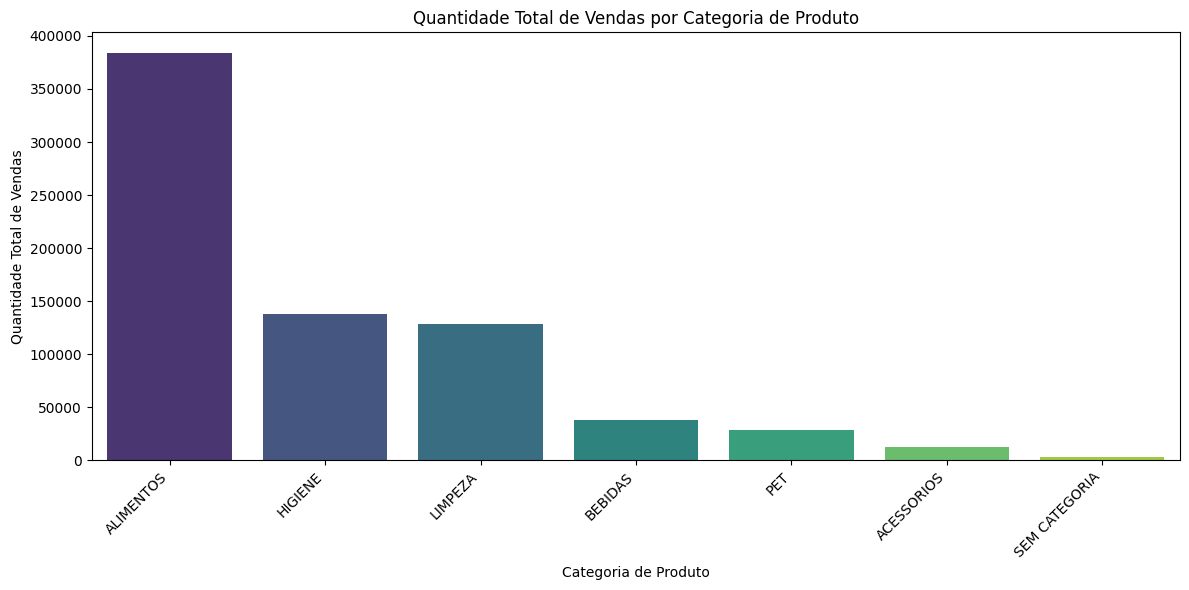

In [30]:
# Gráfico de barras de vendas por categoria de produto
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=vendas_por_categoria,
    x='Categoria de Produto',
    y='Quantidade Total de Vendas',
    palette='viridis'
)
plt.title('Quantidade Total de Vendas por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Quantidade Total de Vendas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# Exportar o dataframe limpo para um arquivo CSV
df_limpo.to_csv('base_varejo_limpa.csv', index=False, sep=';', encoding='cp1252')


## Conclusões

- A base de varejo analisada apresentou grande volume de registros e permitiu observar padrões importantes de consumo por gênero, categoria de produto e produto.

- A categoria `ALIMENTOS` foi a mais frequente na base, com destaque expressivo em relação às demais categorias. Em seguida aparecem `HIGIENE` e `LIMPEZA`, indicando forte presença de produtos essenciais e de consumo recorrente.

- O público feminino apresentou maior quantidade total de registros de compra do que o público masculino. Apesar disso, a tabela dinâmica mostrou que a distribuição das compras por categoria é bastante parecida entre os dois gêneros.

- A análise da coluna `CL_FHL` mostrou concentração de clientes com poucos ou nenhum filho, já que a mediana e a moda foram iguais a `0`, enquanto a média ficou em aproximadamente `1,15` filho por cliente.

- Durante a limpeza, foram identificadas colunas totalmente nulas e categoria e nome inconsistentes (`#N/D`), que foi tratada como `SEM CATEGORIA` e `SEM NOME`, respectivamente. Ainda assim, essa categoria permanece como um ponto de atenção, pois indica produtos sem classificação definida, enquanto foram registradas vendas de produtos que não possuíam nome.

- Uma limitação importante da base é a ausência de uma coluna com valor monetário das vendas. Por isso, as análises realizadas representam quantidade de registros de compra, e não faturamento ou receita gerada.